## Results

In [11]:
from typing import Dict, Any, List, Optional
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('src')

from tiny_hanabi.game.assemblers import get_game, normalize_payoffs
from tiny_hanabi.game.payoff_matrices import OPTIMAL_RETURNS, GameNames

from agents import *
from tiny_game import *
from config import *


sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = [12, 7] # Default figure size

# --- CONFIGURATION ---
RESULTS_BASE_DIR = "Results"
WORLD_MODEL_DIR = os.path.join(RESULTS_BASE_DIR, "WorldModels")
GAMES = ["A", "B", "C", "D", "E", "F", "G"]
PLOT_DIR = "Plots"
os.makedirs(PLOT_DIR, exist_ok = True)
# List of all baseline agent names (ensure these match your Experiment.name in config.py)
BASELINE_AGENT_NAMES = [
    "DTDE QLearning",
    "CTDE VDN",
    "DTDE BI",
    "CTDE BI"
]

TOM_AGENT_NAME = "DTDE ToMBI"


ENVIRONMENTS = {}

for game_name in GAMES:
    ENVIRONMENTS[game_name] = get_game_Rework(GameNames(game_name), normalize = True)


In [12]:
def load_results(agent_name):
    folder = agent_name.replace(" ", "_")
    folder = os.path.join(RESULTS_BASE_DIR, folder)
    assert agent_name in BASELINE_AGENT_NAMES, "WRROOOONG"
    csv_path = os.path.join(folder, "final_results.csv")
    params_path = os.path.join(folder, "best_params.json")

    # Read Params
    with open(params_path) as f:
        params = json.load(f)
    
    # 
    results = pd.read_csv(csv_path)
    print(f"{agent_name} - Overview:")
    print(results.tail(4))
    print()
    agents = {}
    
    for game_name in GAMES:
        # Collect Results

        # Set up Agents
        env = ENVIRONMENTS[game_name]

        exp = next((e for e in BASELINE_EXPERIMENTS if e.name == agent_name), None)
        if exp is None:
            raise ValueError(f"Experiment {agent_name} not found in BASELINE_EXPERIMENTS")

        # Instantiate agents with the best params
        agents_ = exp.make_agents(env, params)
        
        if isinstance(agents, (CTDE_BI_MB_List, CTDE_VDN_MF_List)):
            shared_path = os.path.join(folder, f"G_{game_name}_shared_model.pkl")
            agents.load(shared_path)
        else:
            p0_path = os.path.join(folder, f"G_{game_name}_agent_0.pkl")
            p1_path = os.path.join(folder, f"G_{game_name}_agent_1.pkl")
            agents_[0].load(p0_path)
            agents_[1].load(p1_path)
        agents[game_name] = agents_

    return agents, results, params

In [13]:
agents_BI_CT, results_BI_CT, params_BI_CT = load_results("CTDE BI")
agents_BI_DT, results_BI_DT, params_BI_DT = load_results("DTDE BI")
agents_VDN_CT, results_VDN_CT, params_VDN_CT = load_results("CTDE VDN")
agents_IQL_DT, results_IQL_CT, params_IQL_CT = load_results("DTDE QLearning")

agents_dict = {
    "CTDE BI" : agents_BI_CT,
    "DTDE BI" : agents_BI_DT,
    "CTDE VDN" : agents_VDN_CT,
    "DTDE QLearning" : agents_IQL_DT
}

results_dict = {
    "CTDE BI" : results_BI_CT,
    "DTDE BI" : results_BI_DT,
    "CTDE VDN" : results_VDN_CT,
    "DTDE QLearning" : results_IQL_CT
}

params_dict = {
    "CTDE BI" : params_BI_CT,
    "DTDE BI" : params_BI_DT,
    "CTDE VDN" : params_VDN_CT,
    "DTDE QLearning" : params_IQL_CT
}

CTDE BI - Overview:
   reward_A  loss_A  reward_B  loss_B  reward_C  loss_C  reward_D  loss_D  \
1  0.833333     0.0       0.5     0.0      0.75     0.0      0.75     0.0   
2  0.833333     0.0       0.5     0.0      0.75     0.0      0.75     0.0   
3  0.833333     0.0       0.5     0.0      0.75     0.0      0.75     0.0   
4  0.833333     0.0       0.5     0.0      0.75     0.0      0.75     0.0   

   reward_E  loss_E  reward_F  loss_F  reward_G  loss_G  
1       0.5     0.0  0.777778     0.0     0.625     0.0  
2       0.5     0.0  0.777778     0.0     0.625     0.0  
3       0.5     0.0  0.777778     0.0     0.625     0.0  
4       0.5     0.0  0.777778     0.0     0.625     0.0  

DTDE BI - Overview:
   reward_A  loss_A  reward_B  loss_B  reward_C  loss_C  reward_D  loss_D  \
1  0.583333     0.0       0.5     0.0  0.666667     0.0      0.75     0.0   
2  0.583333     0.0       0.5     0.0  0.666667     0.0      0.75     0.0   
3  0.583333     0.0       0.5     0.0  0.666667     

# Overview

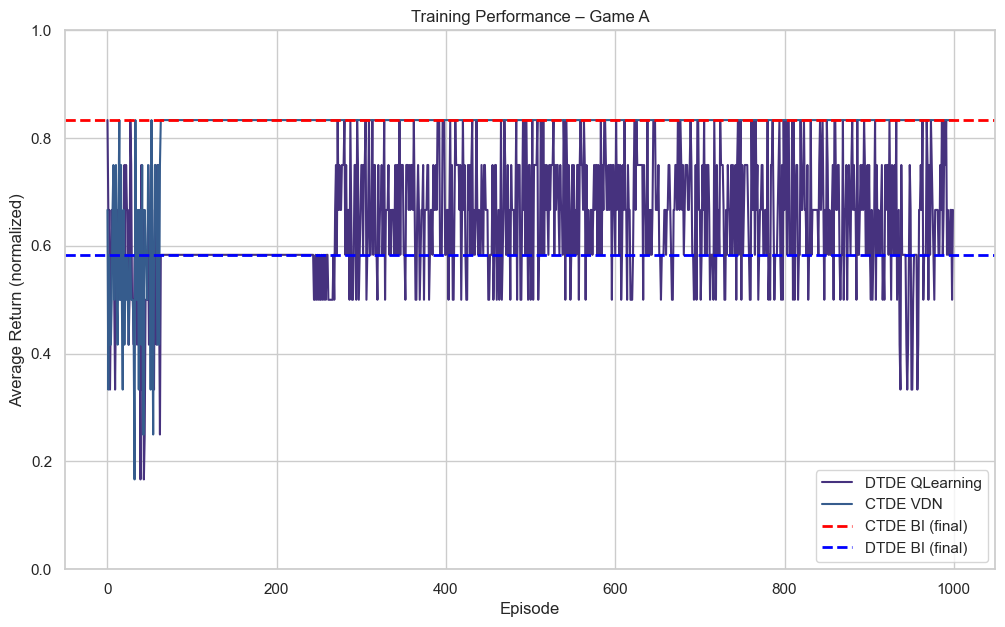

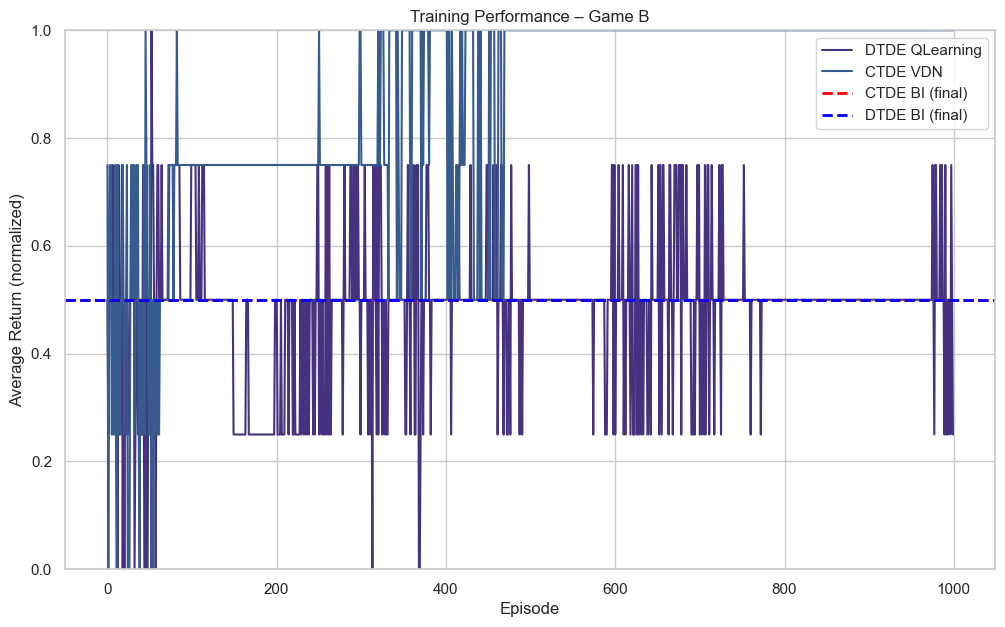

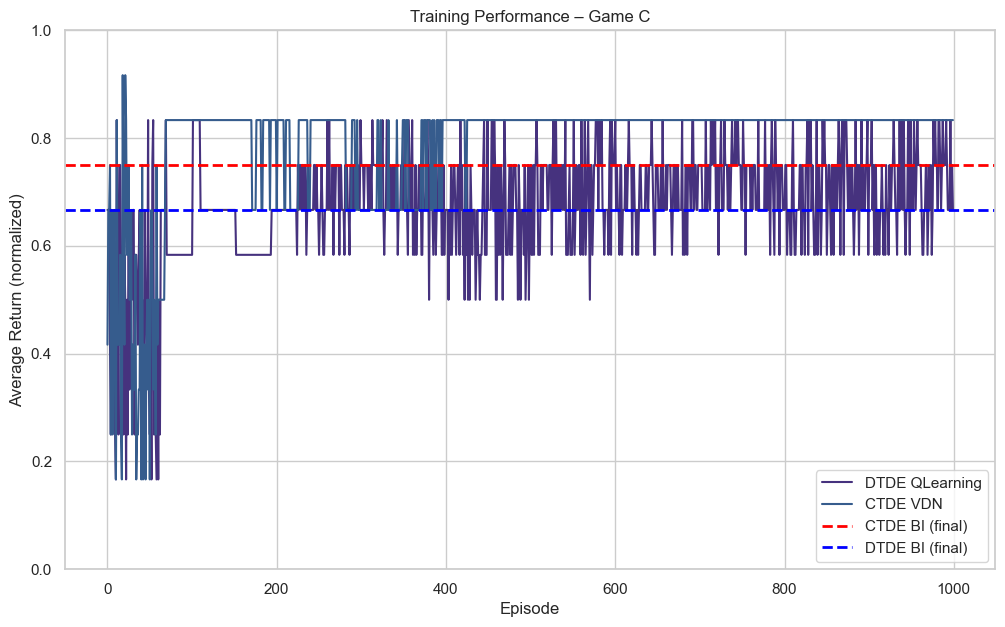

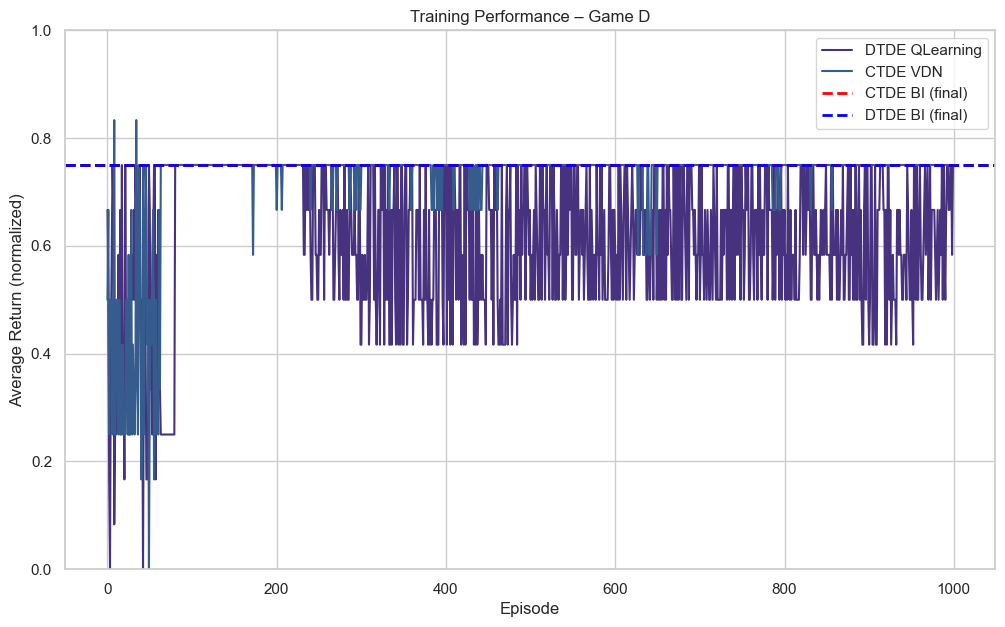

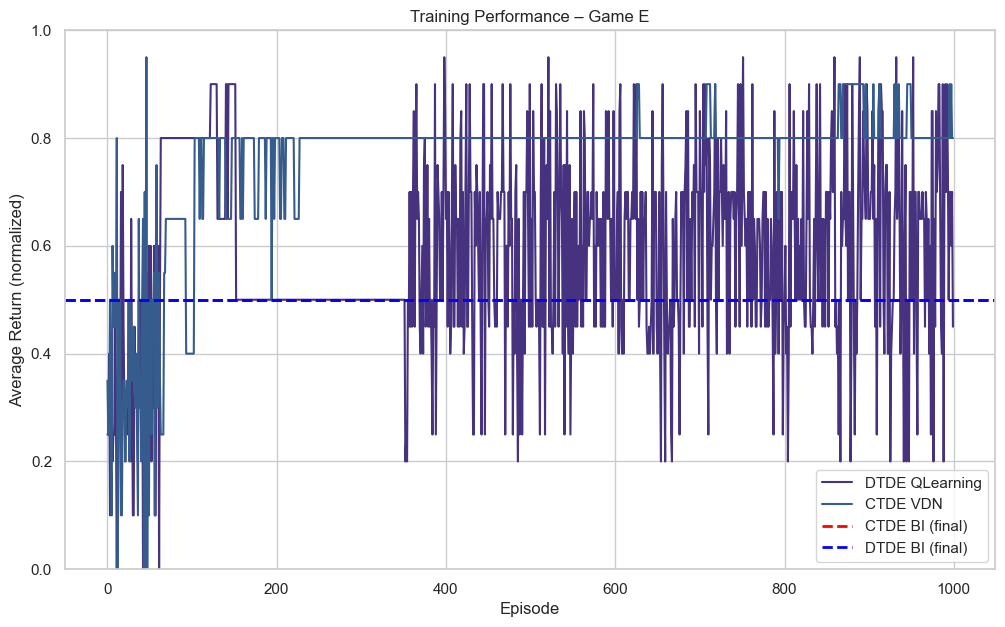

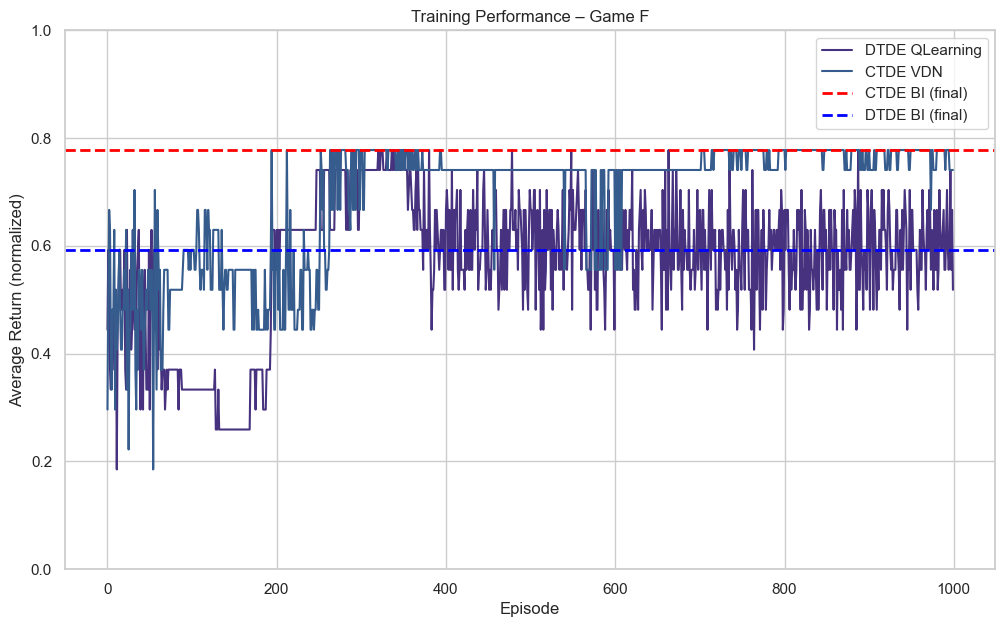

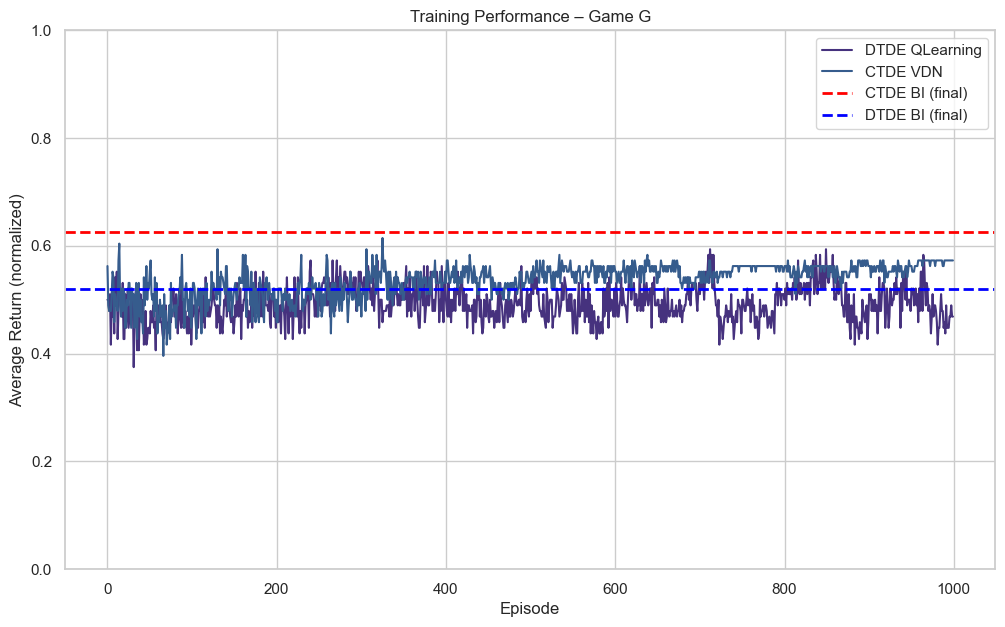

In [16]:
model_free_names = [name for name in BASELINE_AGENT_NAMES if "QLearning" in name or "VDN" in name]
model_based_names = [name for name in BASELINE_AGENT_NAMES if "BI" in name]

r = 1_000
episodes = [i for i in range(r)]
for game in GAMES:
    plt.figure()
    

    data = results_dict["DTDE QLearning"][f"reward_{game}"]
    plt.plot(episodes, data[:r,], label='DTDE QLearning')

    data = results_dict["CTDE VDN"][f"reward_{game}"]
    plt.plot(episodes, data[:r,], label="CTDE VDN")
    # Add horizontal lines for model‑based agents (use last reward value)
        #if data is not None and len(data) > 0:
            #final_reward = data[-1]
    data = results_dict["CTDE BI"][f"reward_{game}"]
    data = data.iloc[-1]
    plt.axhline(y=data, linestyle='--', label=f"CTDE BI (final)", linewidth=2, color='red')
    
    data = results_dict["DTDE BI"][f"reward_{game}"]
    data = data.iloc[-1]
    plt.axhline(y=data, linestyle='--',label=f"DTDE BI (final)", linewidth=2, color='blue')
    

    plt.ylim(0,1.0)
    plt.xlabel("Episode")
    plt.ylabel("Average Return (normalized)")
    plt.title(f"Training Performance – Game {game}")
    plt.legend()
    plot_path = os.path.join(PLOT_DIR, f"general_plot_{game}.png")
    plt.savefig(plot_path)
    plt.show()